In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

In [3]:
# Read in Data

df = pd.read_csv("Reviews.csv")
df = df.head(10000)

#Cleaning Data

df.dropna(inplace=True)
df = df[df['Score'].isin([1, 2, 3, 4, 5])]


# EDA

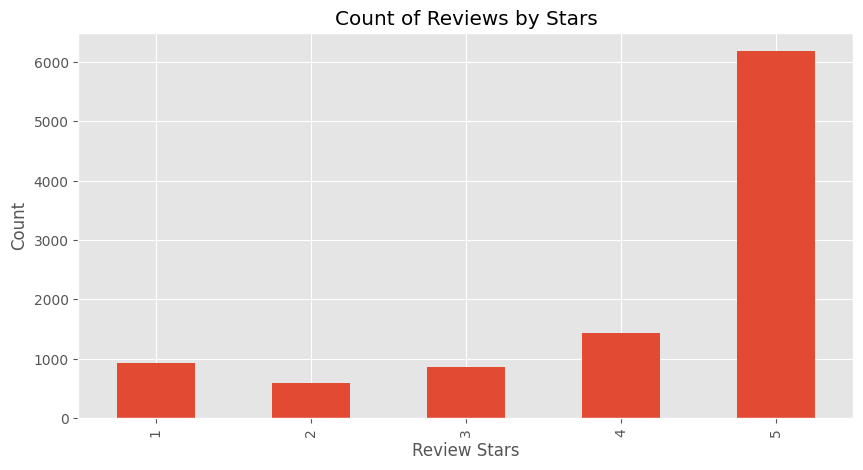

In [4]:
ax = df['Score'].value_counts().sort_index()\
.plot(
    kind='bar',
    title='Count of Reviews by Stars',
    figsize=(10,5)
)

ax.set_xlabel('Review Stars')
ax.set_ylabel('Count')
plt.show()

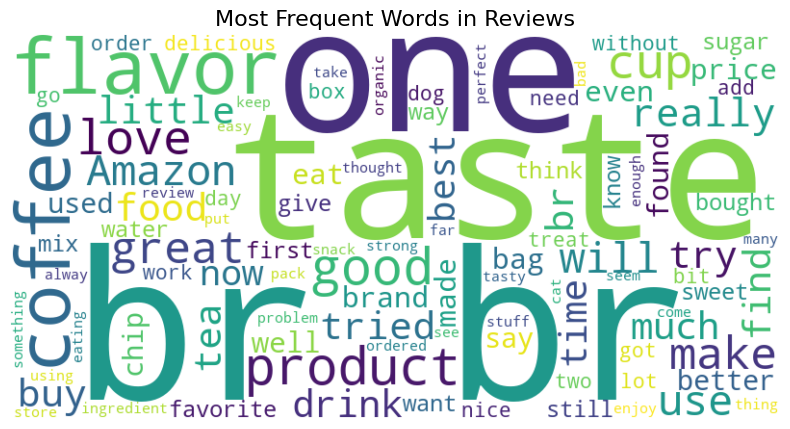

In [5]:
# Word Cloud Visualization of the Most Frequent Terms in User Reviews

from wordcloud import WordCloud

# Combine all review text into one large string
all_text = ' '.join(df['Text'].dropna())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Reviews", fontsize=16)

plt.show()


# NLTK

In [6]:
example = df['Text'][105]
print(example)

I like Creme Brulee. I loved that these were so easy. Just sprinkle on the sugar that came with and broil. They look amazing and taste great. My guess thought I really went out of the way for them when really it took all of 5 minutes. I will be ordering more!


In [7]:
tokens = nltk.word_tokenize(example)
print(tokens[:20])


['I', 'like', 'Creme', 'Brulee', '.', 'I', 'loved', 'that', 'these', 'were', 'so', 'easy', '.', 'Just', 'sprinkle', 'on', 'the', 'sugar', 'that', 'came']


In [8]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]

print(lemmatized_tokens[:20])

['I', 'like', 'Creme', 'Brulee', '.', 'I', 'loved', 'that', 'these', 'were', 'so', 'easy', '.', 'Just', 'sprinkle', 'on', 'the', 'sugar', 'that', 'came']


In [9]:
tagged = nltk.pos_tag(lemmatized_tokens)
tagged[:15]

[('I', 'PRP'),
 ('like', 'VBP'),
 ('Creme', 'NNP'),
 ('Brulee', 'NNP'),
 ('.', '.'),
 ('I', 'PRP'),
 ('loved', 'VBD'),
 ('that', 'IN'),
 ('these', 'DT'),
 ('were', 'VBD'),
 ('so', 'RB'),
 ('easy', 'JJ'),
 ('.', '.'),
 ('Just', 'NNP'),
 ('sprinkle', 'NN')]

In [10]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  I/PRP
  like/VBP
  (PERSON Creme/NNP Brulee/NNP)
  ./.
  I/PRP
  loved/VBD
  that/IN
  these/DT
  were/VBD
  so/RB
  easy/JJ
  ./.
  Just/NNP
  sprinkle/NN
  on/IN
  the/DT
  sugar/NN
  that/WDT
  came/VBD
  with/IN
  and/CC
  broil/NN
  ./.
  They/PRP
  look/VBP
  amazing/VBG
  and/CC
  taste/NN
  great/JJ
  ./.
  My/PRP$
  guess/JJ
  thought/NN
  I/PRP
  really/RB
  went/VBD
  out/IN
  of/IN
  the/DT
  way/NN
  for/IN
  them/PRP
  when/WRB
  really/RB
  it/PRP
  took/VBD
  all/DT
  of/IN
  5/CD
  minute/NN
  ./.
  I/PRP
  will/MD
  be/VB
  ordering/VBG
  more/JJR
  !/.)


# VADER Seniment Scoring

In [11]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [12]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [13]:
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [14]:
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.696, 'pos': 0.304, 'compound': 0.9603}

In [15]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [16]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')

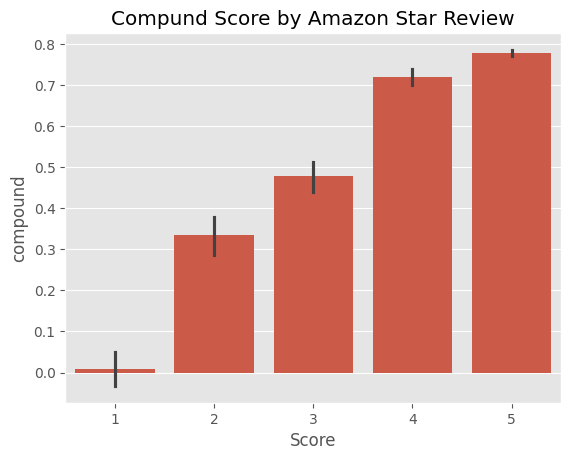

In [17]:
ax = sns.barplot(data=vaders, x='Score', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

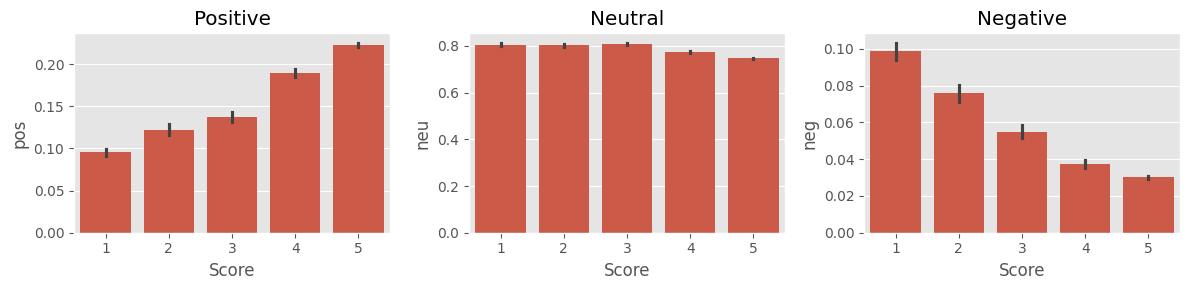

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

# Roberta Pretrained Model

In [19]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [20]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [21]:
from scipy.special import softmax

In [22]:
# Run for Roberta Model
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': np.float32(0.0018723512), 'roberta_neu': np.float32(0.008443224), 'roberta_pos': np.float32(0.98968446)}


In [23]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

# TextBlob

In [24]:
# TextBlob example

from textblob import TextBlob

blob = TextBlob(example)
textblob_result = {
    'textblob_polarity': blob.sentiment.polarity,
    'textblob_subjectivity': blob.sentiment.subjectivity
}
print('TextBlob example:', textblob_result)

TextBlob example: {'textblob_polarity': 0.5083333333333334, 'textblob_subjectivity': 0.5976190476190476}


In [25]:
# Step 3. Apply all three sentiment analyses to the dataset
results = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    
    # VADER
    vader_scores = sia.polarity_scores(text)
    
    # Roberta
    encoded_text = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    
    roberta_scores = {
        'roberta_neg': scores[0],
        'roberta_neu': scores[1],
        'roberta_pos': scores[2]
    }
    
    # TextBlob
    blob = TextBlob(text)
    textblob_scores = {
        'textblob_polarity': blob.sentiment.polarity,
        'textblob_subjectivity': blob.sentiment.subjectivity
    }
    
    results.append({
        'Id': myid,
        **vader_scores,
        **roberta_scores,
        **textblob_scores
    })

  0%|          | 0/10000 [00:00<?, ?it/s]

In [26]:
sentiments = pd.DataFrame(results)
sentiments = sentiments.merge(df, how='left')

# Combine and compare

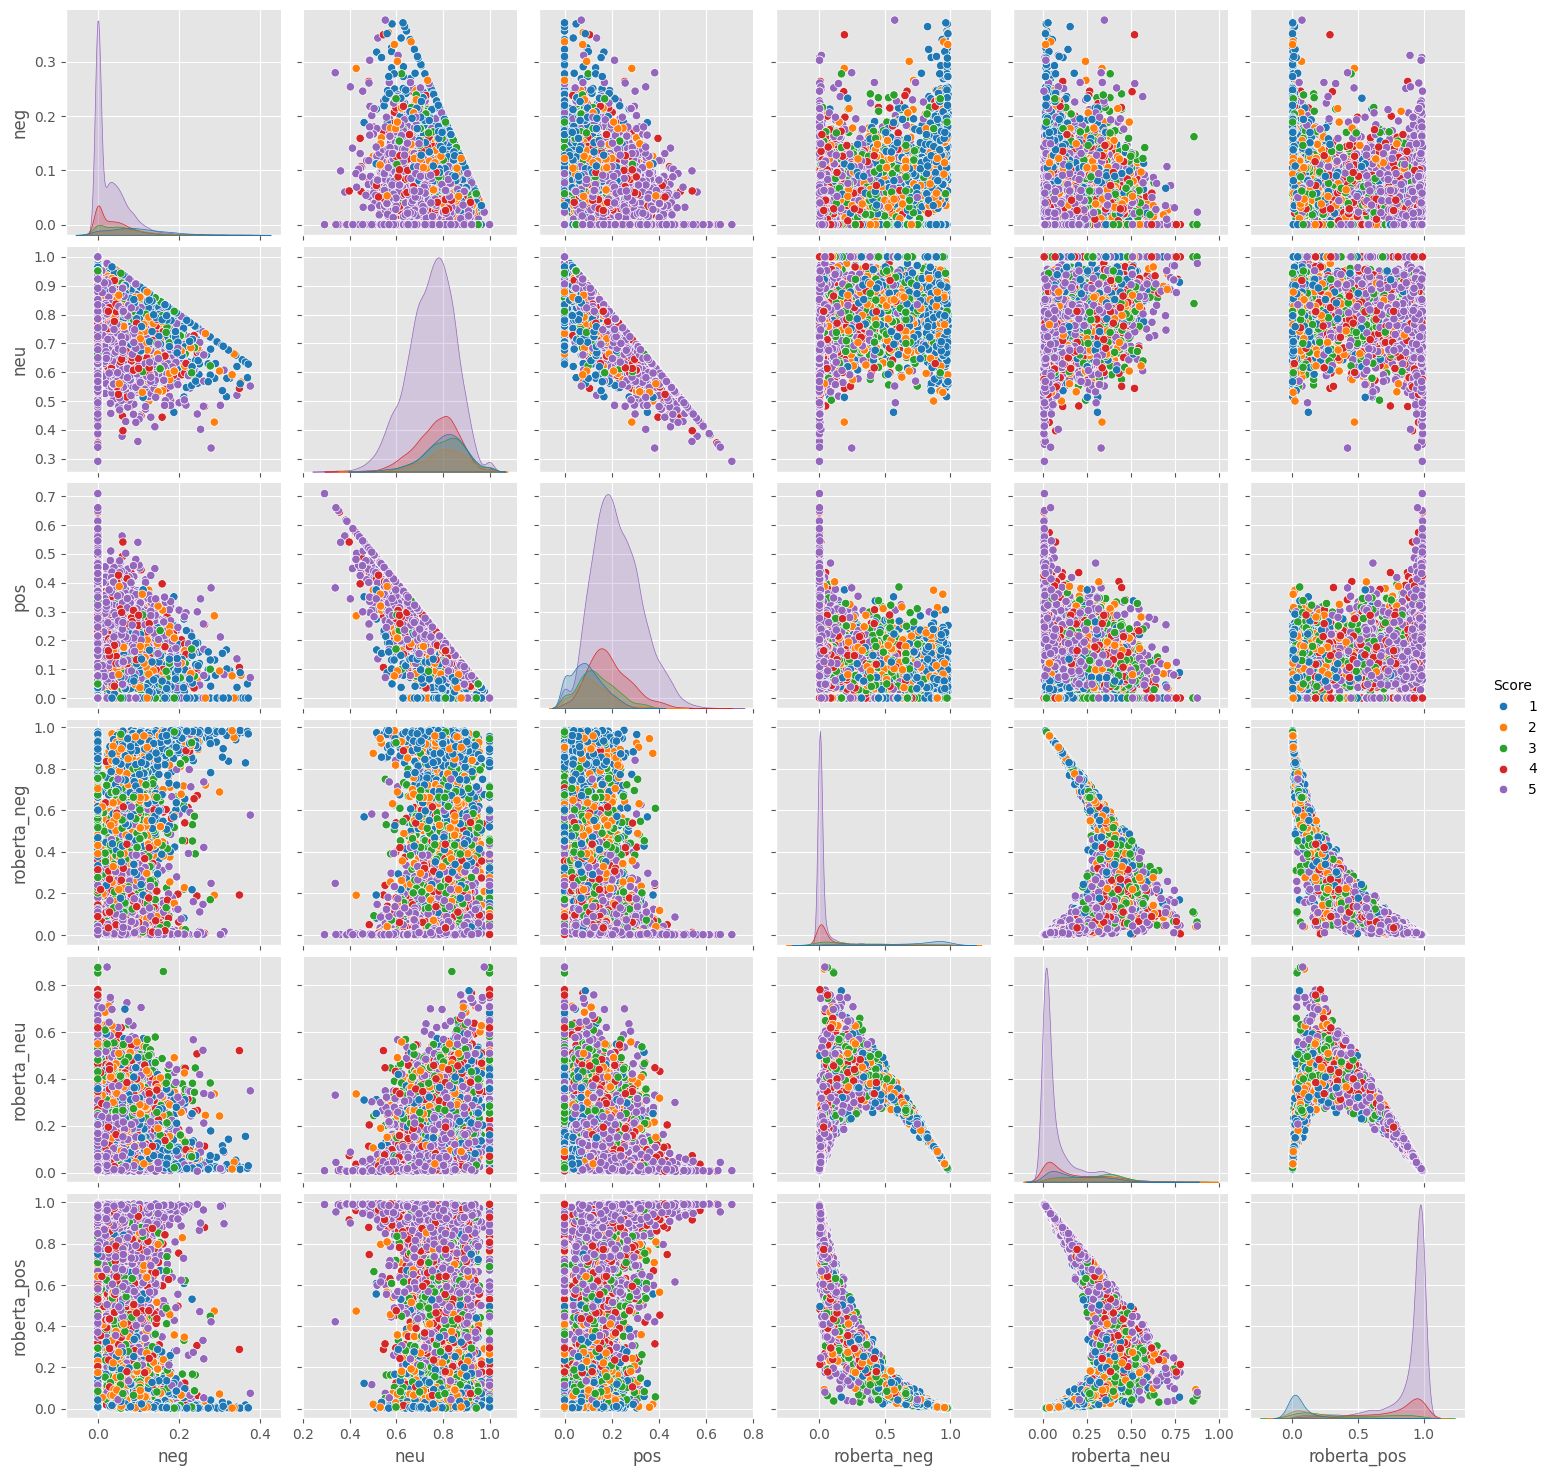

In [27]:
sns.pairplot(
    data=sentiments,
    vars=['neg', 'neu', 'pos', 'roberta_neg', 'roberta_neu', 'roberta_pos'],
    hue='Score',
    palette='tab10'
)
plt.show()


# Comparison of Sentiment Analysis Models Across Star Ratings

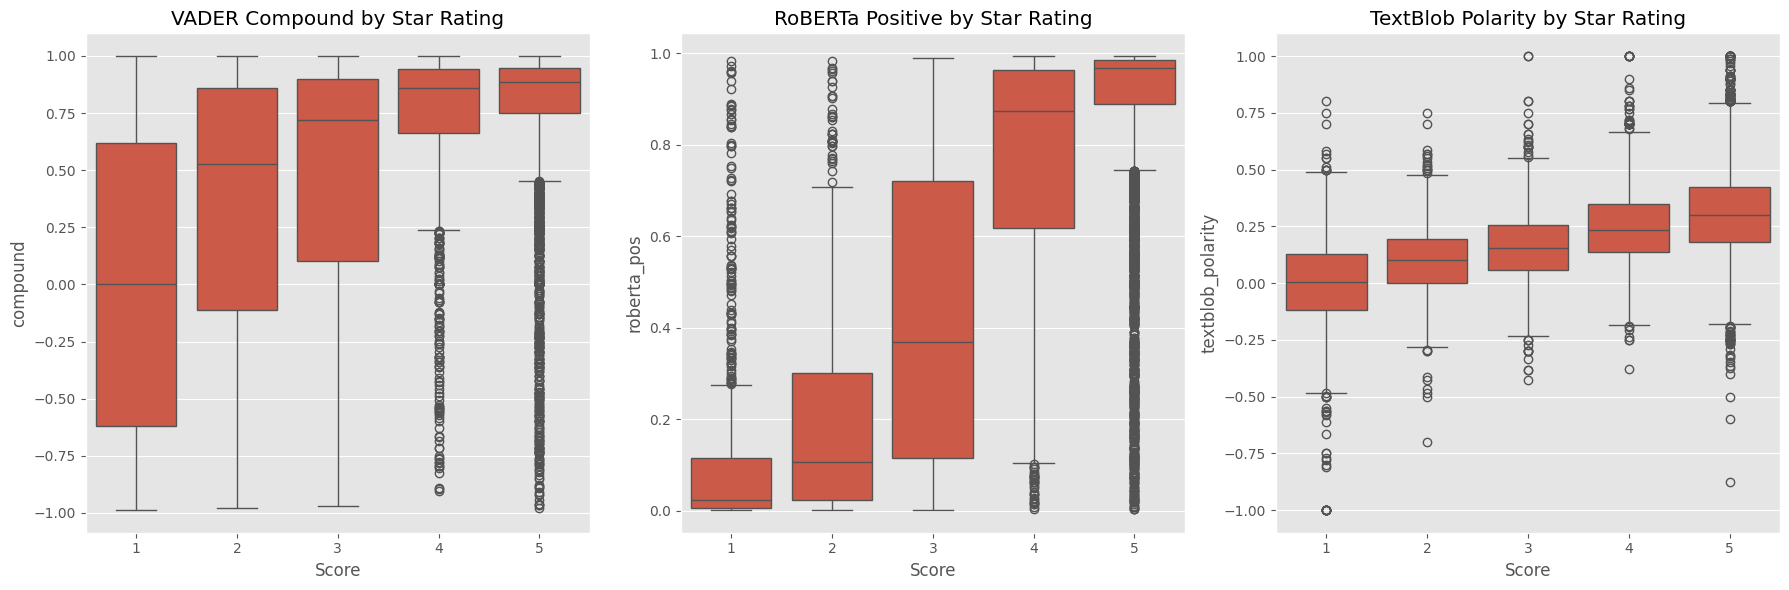

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=sentiments, x='Score', y='compound', ax=axs[0])
axs[0].set_title('VADER Compound by Star Rating')

sns.boxplot(data=sentiments, x='Score', y='roberta_pos', ax=axs[1])
axs[1].set_title('RoBERTa Positive by Star Rating')

sns.boxplot(data=sentiments, x='Score', y='textblob_polarity', ax=axs[2])
axs[2].set_title('TextBlob Polarity by Star Rating')

plt.tight_layout()
plt.show()


# Review Examples

In [29]:
# 1-Star with highest Roberta Positive score
print("Roberta Positive (1-Star):")
print(sentiments.query('Score == 1').sort_values('roberta_pos', ascending=False)['Text'].values[0])


Roberta Positive (1-Star):
Bisquick GF is easy to use. Pancakes and muffins are very<br />tasty. The product is quick and easy to use. It makes my day.  Gram


In [30]:
# 1-Star with highest VADER Positive score
print("VADER Positive (1-Star):")
print(sentiments.query('Score == 1').sort_values('pos', ascending=False)['Text'].values[0])



VADER Positive (1-Star):
This flavor is horrible.  There are many other flavors much better.  Hawaiian Hazelnut is great!  Breakfast in Bed is AWesome!


In [31]:
# 1-Star with highest TextBlob Polarity score
print("TextBlob Polarity (1-Star):")
print(sentiments.query('Score == 1').sort_values('textblob_polarity', ascending=False)['Text'].values[0])


TextBlob Polarity (1-Star):
Hi, coffee doesn't smell or taste great. I recommend Senseo Vienna. Still have packages of "Paris" and nobody wanna drink it. Guess I just have to throw it away.


In [32]:
# 5-Star with highest Roberta Negative score
print("Roberta Negative (5-Star):")
print(sentiments.query('Score == 5').sort_values('roberta_neg', ascending=False)['Text'].values[0])


Roberta Negative (5-Star):
They have a bad taste,i finish giving them away because my son started to cry everytime i tried to give these.I prefer Beech nut or Gerber.Yuck!


In [33]:
# 5-Star with highest VADER Negative score
print("VADER Negative (5-Star):")
print(sentiments.query('Score == 5').sort_values('neg', ascending=False)['Text'].values[0])


VADER Negative (5-Star):
My two cats must not be interested in grass, because it grew but they ignored it. Had no problems growing it.


In [34]:
# 5-Star with lowest TextBlob Polarity score (more negative)
print("TextBlob Polarity (5-Star):")
print(sentiments.query('Score == 5').sort_values('textblob_polarity', ascending=True)['Text'].values[0])


TextBlob Polarity (5-Star):
They have a bad taste,i finish giving them away because my son started to cry everytime i tried to give these.I prefer Beech nut or Gerber.Yuck!
